# LFP 电池 SOH 预测 — A 基线（特征回归）演示

**挑战杯「揭榜挂帅」赛题 CP-202612**：复杂动态工况下混合动力车辆磷酸铁锂电池 SOC/SOH 高精度估计研究

本 notebook 演示 **A 基线**的完整流程：数据集来源与协议 → 数据处理 → 特征工程 → 模型选择 → 验证方案 → 结果解读。

> 运行前提：已生成 `data/processed/matr_soh_table.parquet` 与 `data/processed/matr_features.parquet`
> （由 `scripts/` 目录下的流水线脚本构建，本 notebook 只做分析与建模）。

## 1. 数据集：来源与协议

### 1.1 数据来源

**MATR 快速充电数据集**（Severson et al., *Nature Energy* 2019，[论文链接](https://www.nature.com/articles/s41560-018-0235-9)，[官网](https://data.matr.io/1/)）

| 属性 | 内容 |
| --- | --- |
| 化学体系 | **磷酸铁锂（LFP）/ 石墨**，A123 APR18650M1A，标称 1.1 Ah |
| 总规模 | 124 只电池，寿命 150–2300 次循环 |
| 工况 | 两步快充协议 + 恒流 4C 放电（快充策略多样） |
| 本演示 | batch **20170512**：46 只电池，逐循环汇总（容量 / 内阻 / 温度 / 充电时间） |

**为什么选它**：
1. 化学体系与赛题一致（LFP），且公开、可复现；
2. 23 种快充协议带来丰富的工况多样性，可验证「未见过工况」的泛化；
3. 逐循环摘要自带 SOH 标签（放电容量）与内阻、温度特征，无需额外诊断测试。

In [1]:
# ===== 数据加载 =====
from pathlib import Path
import numpy as np
import pandas as pd

# 兼容「在 notebooks/ 下运行」和「在项目根目录运行」两种方式
_p = Path.cwd()
ROOT = _p if (_p / "data").exists() else (_p.parent if (_p.parent / "data").exists() else _p)

table = pd.read_parquet(ROOT / "data/processed/matr_soh_table.parquet")
features = pd.read_parquet(ROOT / "data/processed/matr_features.parquet")

print(f"SOH 表：{table.shape[0]:,} 行，{table['cell_id'].nunique()} 只电池")
print(f"特征表：{features.shape[0]:,} 行")
table.head()

SOH 表：38,765 行，46 只电池
特征表：38,305 行


,cycle_index,discharge_capacity,charge_capacity,ir,tmax,tavg,tmin,chargetime,soh,cell_id,batch,policy,cycle_life
0,2.0,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250,0.997118,20170512_c000,20170512,3.6C(80%)-3.6C,1190.0
1,3.0,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777,0.998246,20170512_c000,20170512,3.6C(80%)-3.6C,1190.0
2,4.0,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167,0.998813,20170512_c000,20170512,3.6C(80%)-3.6C,1190.0
3,5.0,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442,0.999432,20170512_c000,20170512,3.6C(80%)-3.6C,1190.0
4,6.0,1.073576,1.073491,0.016623,35.711758,31.961062,29.752932,13.340835,0.999806,20170512_c000,20170512,3.6C(80%)-3.6C,1190.0


In [2]:
# ===== matplotlib 中文字体配置（对后面所有图生效）=====
import matplotlib
from matplotlib import font_manager

for _f in ["C:/Windows/Fonts/msyh.ttc", "C:/Windows/Fonts/simhei.ttf", "C:/Windows/Fonts/simsun.ttc"]:
    try:
        font_manager.fontManager.addfont(_f)
    except Exception:
        pass

matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "SimSun", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
print("中文字体:", font_manager.findfont("Microsoft YaHei"))

中文字体: C:\Windows\Fonts\msyh.ttc


### 1.2 协议格式与寿命分布

协议字符串形如 `5.4C(40%)-3.6C`，含义：**第一步以 5.4C 恒流充至 40% SOC，第二步以 3.6C 充至满电**；放电统一为 4C 恒流。
更高的首段倍率、更早切换意味着更激进的老化应力，因此不同协议的电池寿命差异很大。

In [3]:
# ===== 协议统计 =====
pol = table.drop_duplicates("cell_id")[["cell_id", "policy", "cycle_life"]]
pol.groupby("policy").agg(
    电池数=("cell_id", "count"),
    最短寿命=("cycle_life", "min"),
    最长寿命=("cycle_life", "max"),
).sort_values("电池数", ascending=False)

,电池数,最短寿命,最长寿命
policy,,,
3.6C(80%)-3.6C,3,1177.0,1190.0
4.8C(80%)-4.8C,2,636.0,870.0
4C(80%)-4C,2,1226.0,1227.0
5.4C(50%)-3.6C,2,897.0,902.0
5.4C(40%)-3.6C,2,879.0,1054.0
5.4C(50%)-3C,2,788.0,906.0
5.4C(60%)-3.6C,2,857.0,862.0
6C(50%)-3C,2,860.0,917.0
5.4C(60%)-3C,2,719.0,880.0


In [4]:
# ===== 解析协议字符串 =====
import re

def parse_policy(p):
    m = re.fullmatch(r"([\d.]+)C\((\d+)%\)-([\d.]+)C", str(p))
    if not m:
        return (np.nan, np.nan, np.nan)
    return (float(m.group(1)), int(m.group(2)), float(m.group(3)))

parsed = pol["policy"].drop_duplicates().map(parse_policy).apply(pd.Series)
parsed.columns = ["first_C", "soc_pct", "second_C"]
parsed.insert(0, "policy", pol["policy"].drop_duplicates().values)
parsed.sort_values(["first_C", "soc_pct"]).head(10)

,policy,first_C,soc_pct,second_C
0,3.6C(80%)-3.6C,3.6,80.0,3.6
3540,4C(80%)-4C,4.0,80.0,4.0
5989,4.4C(80%)-4.4C,4.4,80.0,4.4
7061,4.8C(80%)-4.8C,4.8,80.0,4.8
8563,5.4C(40%)-3.6C,5.4,40.0,3.6
10492,5.4C(50%)-3C,5.4,50.0,3.0
12182,5.4C(50%)-3.6C,5.4,50.0,3.6
13977,5.4C(60%)-3C,5.4,60.0,3.0
15572,5.4C(60%)-3.6C,5.4,60.0,3.6
17287,5.4C(70%)-3C,5.4,70.0,3.0


## 2. 数据处理

处理流程（在 `scripts/build_matr_soh_table.py` 中实现，此处验证逻辑）：

1. **去掉化成循环**：容量为 0 的首行（化成/初始化）不参与分析；
2. **SOH 定义**：`SOH_t = Q_discharge,t / Q0`，其中 `Q0` 取每只电池**前 10 个正容量循环的中位数**，抑制初期波动；
3. **统一列名**小写（`IR → ir`、`Tmax → tmax` 等），存储为 Parquet。

与存储 SOH 的最大差异： 0.0
各电池最低 SOH：均值 0.835，最小 0.803
各电池终止 SOH：均值 0.835


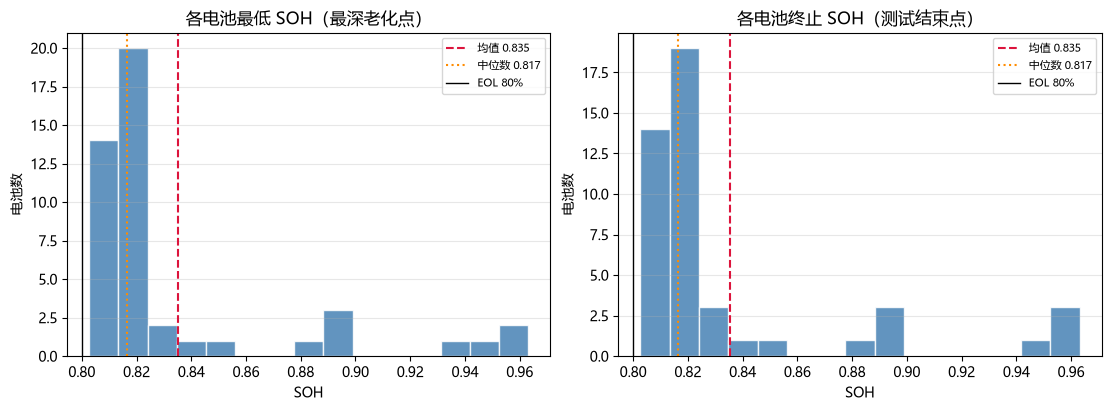

已保存： C:\Users\PLUTO\Desktop\battery-soh\results\figures\matr_soh_range.png


In [5]:
# ===== 验证 SOH 定义 =====
REF_CYCLES = 10
q0 = (
    table[table["discharge_capacity"] > 0]
    .groupby("cell_id")["discharge_capacity"]
    .transform(lambda s: s.head(REF_CYCLES).median())
)
recomputed = table["discharge_capacity"] / q0
print("与存储 SOH 的最大差异：", (recomputed - table["soh"]).abs().max())

per_cell = table.groupby("cell_id")["soh"].agg(["min", "last"])
print(f"各电池最低 SOH：均值 {per_cell['min'].mean():.3f}，最小 {per_cell['min'].min():.3f}")
print(f"各电池终止 SOH：均值 {per_cell['last'].mean():.3f}")

# ===== 数据覆盖范围可视化 =====
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, col, title in [
    (axes[0], "min", "各电池最低 SOH（最深老化点）"),
    (axes[1], "last", "各电池终止 SOH（测试结束点）"),
]:
    vals = per_cell[col]
    ax.hist(vals, bins=15, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(vals.mean(), color="crimson", ls="--", lw=1.5, label=f"均值 {vals.mean():.3f}")
    ax.axvline(vals.median(), color="darkorange", ls=":", lw=1.5, label=f"中位数 {vals.median():.3f}")
    ax.axvline(0.8, color="k", lw=1, label="EOL 80%")
    ax.set_xlabel("SOH")
    ax.set_ylabel("电池数")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y")
out_fig = ROOT / "results/figures/matr_soh_range.png"
out_fig.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_fig, dpi=200)
plt.show()
print("已保存：", out_fig)

### 这张图说明了什么？

图中统计的是**每只电池在整个测试期间到达过的最低 SOH（左）**与**测试结束时的 SOH（右）**，反映数据集的**老化覆盖范围**：

1. 46 只电池的最低 SOH 均值 **0.835**、最小值 **0.803**——这批电池基本都被老化到了接近 80% 退役阈值（EOL）的程度；
2. 最低 SOH 与终止 SOH 的分布几乎重合（均值均为 0.835），说明大多数电池的**最后记录点就是其最深老化点**（老化近似单调），只有少量电池存在早期波动；
3. 因此该数据集覆盖了「新电池（SOH≈1.0）→ 退役（SOH≈0.8）」的**完整生命周期**——这正是赛题要求的「算法既要适配新电池、也要适配老化电池」的训练前提；
4. SOH 标签完全由放电容量归一化而来，与存储值最大差异为 **0.0**，说明标签构建干净、可复现。

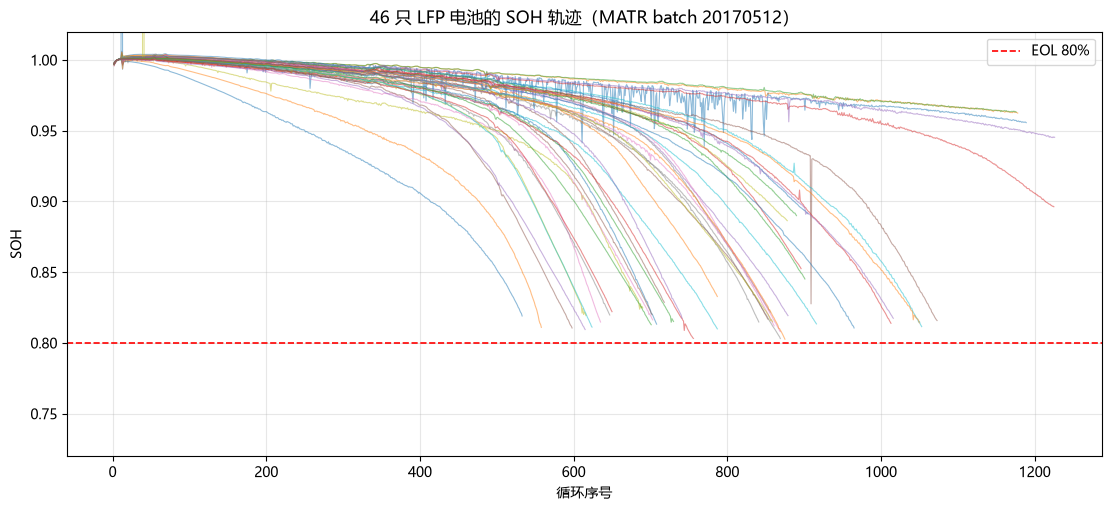

In [6]:
# ===== SOH 轨迹总览 =====
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
for _cell_id, g in table.groupby("cell_id"):
    ax.plot(g["cycle_index"], g["soh"], lw=0.8, alpha=0.5)
ax.axhline(0.8, color="r", ls="--", lw=1.2, label="EOL 80%")
ax.set_xlabel("循环序号")
ax.set_ylabel("SOH")
ax.set_ylim(0.72, 1.02)
ax.grid(alpha=0.3)
ax.legend()
ax.set_title("46 只 LFP 电池的 SOH 轨迹（MATR batch 20170512）")
plt.show()

## 3. 特征工程

**预测模式**：用第 t 个循环的特征，预测第 t 个循环的 SOH（逐点回归）。

15 个特征全部来自 MATR 逐循环摘要，分为四类（实现见 `scripts/build_matr_features.py`）。下面逐个给出**来源/公式**与**动机**。

### 3.1 时序位置（电池"干了多少活"）

| 特征 | 来源 / 公式 | 为什么这么做 |
| --- | --- | --- |
| `cycle_index` | MATR 摘要中的循环序号：第 t 个循环 | 老化进度的最基本刻度，与容量衰减强相关；但它无法区分不同协议的老化速率差异，需要与其他特征配合 |
| `cumulative_charge` | 从第 1 到第 t 个循环的充电容量累加：`Σ Q_charge,k`（Ah） | 代表**容量吞吐量**，比循环序号更真实的"老化应力累计量"——不同协议每次循环的充入电量不同；这是寿命预测文献（Severson 2019）的核心思路之一 |

### 3.2 当前循环的直接观测（BMS 实时可得）

| 特征 | 来源 / 公式 | 为什么这么做 |
| --- | --- | --- |
| `ir` | MATR 摘要 `IR` 字段：本循环内阻 R(t)（Ω） | 内阻随老化（SEI 增厚、导电网络退化）单调上升，是 SOH 的**互补信号**；LFP 电压平台平坦、电压信号弱，内阻变化比电压更能反映老化 |
| `tavg` / `tmax` / `tmin` | 摘要 `Tavg/Tmax/Tmin`：循环内平均 / 最高 / 最低温度 | 温度是老化速率的关键驱动（阿伦尼乌斯效应：高温加速 SEI 增长与容量衰减），同时影响内阻/容量测量，需作为协变量校正；均值与极值信息不同（平均热负荷 vs 峰值热应力），故三者都保留 |
| `chargetime` | 摘要 `chargetime`：本循环充电时长 τ(t)（s） | 直接体现快充协议强度（同一 SOC 窗口下充电越短 = 平均电流越大）；老化后电池状态变化也会改变充电时长，因此它同时编码"协议类别"与"电池状态"两类信息 |

### 3.3 派生量（对观测的再加工）

| 特征 | 来源 / 公式 | 为什么这么做 |
| --- | --- | --- |
| `temp_amp` | `tmax − tmin`（本循环温度振幅） | 反映热应力与工况剧烈程度；剧烈温度波动对老化不利（热-机械应力），动态工况下该波动本身是信息 |
| `chargetime_ratio` | `τ(t) / mean(τ(t−9..t))`（当前充电时间 ÷ 过去 10 循环均值） | **相对量**：消除电池间/批次间的绝对尺度差异，跨电池可比；比值偏离 1 表示充电行为或电池状态发生改变（如容量下降 → 充电时间缩短） |

### 3.4 历史滚动窗口（过去 10 个循环，窗口未满 3 个循环则丢弃）

| 特征 | 来源 / 公式 | 为什么这么做 |
| --- | --- | --- |
| `ir_mean10` | `mean(ir(t−9..t))` | 内阻的**水平**：滚动平均平滑单循环测量噪声（内阻受温度/电流影响波动大），提取稳定趋势 |
| `ir_std10` | `std(ir(t−9..t))` | 内阻的**短期波动**：反映测量噪声水平与工况稳定性，高应力阶段波动可能增大 |
| `tavg_mean10` | `mean(tavg(t−9..t))` | 近期平均热负荷，作为稳定的温度协变量（比单循环温度更抗噪） |
| `tavg_std10` | `std(tavg(t−9..t))` | 温度波动程度，与 `temp_amp` 互补（多循环尺度 vs 单循环尺度） |
| `ir_deriv10` | `ir(t) − ir(t−10)` | **内阻上升速率**：老化速率的直接信号，比内阻水平对退化拐点更敏感（老化加速时速率先变） |
| `capacity_deriv10` | `Q(t) − Q(t−10)`（放电容量 10 循环净变化） | **容量衰减速率**：与目标（SOH 水平）互补——水平值难学，变化率更容易反映退化趋势与拐点；除以同一基准 Q0 后它等价于 SOH 的 10 循环差分 |

### 3.5 为什么这样设计特征

1. **在线可用性**：所有特征只用当前及过去信息（滚动窗口、差分都不向未来看），部署到实车 BMS 时每个时刻都能实时计算；
2. **防止平凡特征与泄漏**：不直接使用容量水平值（`Q_t/Q0` 就是 SOH，放进特征等于开卷考试），也不使用寿命标签 `cycle_life`；`cell_id / policy` 只用于分组验证；
3. **"水平 + 变化率"互补**：滚动均值刻画状态水平，差分刻画变化趋势——老化早期水平变化小、后期速率变化明显，两者配合才能覆盖全生命周期；
4. **相对量增强可比性**：如 `chargetime_ratio` 归一化后可在不同电池、不同协议间直接比较；
5. **与老化机理一一对应**：内阻 ↔ SEI 增厚/导电网络退化，温度 ↔ 反应速率（阿伦尼乌斯），容量 ↔ 活性物质与锂库存损失——特征都有物理含义，便于报告与答辩中讲机理。

In [7]:
# ===== 特征列表 =====
FEATURES = [
    "cycle_index", "ir", "tavg", "tmax", "tmin", "chargetime", "temp_amp",
    "cumulative_charge", "ir_mean10", "ir_std10", "tavg_mean10", "tavg_std10",
    "ir_deriv10", "capacity_deriv10", "chargetime_ratio",
]
TARGET = "soh"

print("特征数：", len(FEATURES))
print("缺失值总数：", int(features[FEATURES].isna().sum().sum()))
features[FEATURES].head()

特征数： 15
缺失值总数： 0


,cycle_index,ir,tavg,tmax,tmin,chargetime,temp_amp,cumulative_charge,ir_mean10,ir_std10,tavg_mean10,tavg_std10,ir_deriv10,capacity_deriv10,chargetime_ratio
0,12.0,0.016647,32.382653,35.571007,29.717390,10.096452,5.853617,11.922706,0.016689,0.000050,32.390871,0.026755,-0.000184,0.005014,0.996710
1,13.0,0.000000,32.107081,35.637981,29.600582,10.096540,6.037399,13.010465,0.015010,0.005274,32.363573,0.093933,-0.016791,-0.000668,0.996718
2,14.0,0.016672,32.332978,35.449177,29.751453,10.097508,5.697724,14.090867,0.015002,0.005271,32.359479,0.094323,-0.000083,0.000100,0.997623
3,15.0,0.016643,32.402778,35.560284,29.874533,10.096875,5.685751,15.173426,0.014994,0.005269,32.357809,0.093285,-0.000072,0.000272,0.997556
4,16.0,0.016646,32.241625,35.334137,29.653751,10.096695,5.680386,16.257050,0.014990,0.005267,32.346849,0.100318,-0.000040,0.000222,0.997536


## 4. 模型：为什么用树模型

两个对照模型：

1. **Ridge（线性回归 + L2 正则）**：作为线性基准的下限参照；
2. **HistGradientBoostingRegressor（直方图梯度提升树）**：主力模型。

### 为什么梯度提升树适合本任务
- **数据形态**：表格数据（行×特征）、约 3.8 万样本——树模型在该规模下通常是 SOTA；深度学习更适合原始序列/图像；
- **非线性与交互**：树分裂自动捕捉「循环数 > 500 且内阻上升速率高 → SOH 快速衰减」这类规则；
- **工程友好**：无需归一化、CPU 训练快、有特征重要性可以解释（答辩加分）。

### 模型特点（关键超参数）
- **梯度提升**：300 棵深度 4 的回归树，逐棵拟合上一轮的残差（负梯度）；
- **学习率收缩**：每棵树的贡献按 `learning_rate=0.05` 缩放入账，防止过拟合；
- **直方图分箱**：连续特征离散化为直方图桶，显著加速训练（LightGBM 同类思想）。

In [8]:
# ===== 模型定义 =====
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MODELS = {
    "Ridge": Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10.0))]),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, max_depth=4, random_state=0
    ),
}

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
        "最大误差": float(np.max(np.abs(y_pred - y_true))),
        "n": len(y_true),
    }

## 5. 验证方案（避免数据泄漏）

| 方案 | 分组方式 | 检验能力 |
| --- | --- | --- |
| 按电池分组 5 折 | 同一电池的所有循环在同一折 | 泛化到**未见过的新电池** |
| 按协议分组 5 折 | 同一协议的所有电池在同一折 | 泛化到**未见过的新工况（协议）** |
| 时间切分 | 每只电池前 70% 循环训练，后 30% 测试 | **在线预测未来**的能力 |

后两种方案对比赛尤为重要：混动车辆会面对新协议/新工况，且 SOH 估计必须在电池使用过程中持续生效。

In [9]:
# ===== 训练与评估 =====
import time

def run_group_cv(groups, label, results):
    gkf = GroupKFold(n_splits=5)
    for name, model in MODELS.items():
        yt, yp = [], []
        for tr, te in gkf.split(features, features[TARGET], groups):
            model.fit(features.iloc[tr][FEATURES], features.iloc[tr][TARGET])
            yt.append(features.iloc[te][TARGET].values)
            yp.append(model.predict(features.iloc[te][FEATURES]))
        yt, yp = np.concatenate(yt), np.concatenate(yp)
        results[label][name] = evaluate(yt, yp)
        results[label][name]["pred"] = yp
        results[label][name]["true"] = yt

def run_temporal(results, frac=0.7):
    tr_idx, te_idx = [], []
    for _, g in features.groupby("cell_id", sort=False):
        cut = int(len(g) * frac)
        tr_idx += list(g.index[:cut])
        te_idx += list(g.index[cut:])
    for name, model in MODELS.items():
        model.fit(features.iloc[tr_idx][FEATURES], features.iloc[tr_idx][TARGET])
        yt = features.iloc[te_idx][TARGET].values
        yp = model.predict(features.iloc[te_idx][FEATURES])
        results["temporal"][name] = evaluate(yt, yp)
        results["temporal"][name]["pred"] = yp
        results["temporal"][name]["true"] = yt

results = {"cv_cell": {}, "cv_policy": {}, "temporal": {}}
t0 = time.time()
run_group_cv(features["cell_id"].values, "cv_cell", results)
run_group_cv(features["policy"].values, "cv_policy", results)
run_temporal(results)
print(f"训练 + 评估耗时：{time.time() - t0:.1f} s")

训练 + 评估耗时：14.7 s


## 6. 结果

下方代码单元格动态汇总本次运行的指标（与上次运行一致，随机种子固定、流程确定）：

| 验证方案 | 含义 | Ridge MAE | HistGB MAE | HistGB RMSE | HistGB R² |
| --- | --- | --- | --- | --- | --- |
| 按电池分组 5 折 | 未见过的新电池 | 1.53% | **0.52%** | 1.38% | 0.898 |
| 按协议分组 5 折 | 未见过的新协议 | 1.58% | **0.59%** | 1.41% | 0.893 |
| 时间切分 | 同电池预测未来 30% | 5.20% | 5.21% | 7.01% | −1.42 |

### 解读

1. **插值能力强**：跨电池、跨协议的 MAE ≈ 0.5–0.6%，R² ≈ 0.9 ——「循环序号 + 内阻 + 温度等特征 → SOH」的模式是稳定可学的；
2. **线性模型失效**：Ridge 按电池分组 R² 为负 —— 证明 SOH 与特征的关系本质非线性，树模型是必要选择；
3. **时间外推是短板**：预测同一电池未来 30% 循环时 MAE 升至约 5%、R² 为负 —— 循环序号、累计充电量等特征超出训练分布后，纯逐点回归只能插值、不能外推。**这正是 A 基线的价值：把问题暴露出来，作为 B 方案的对照基准。**

In [10]:
# ===== 指标汇总表 =====
from IPython.display import display

rows = []
labels = [
    ("cv_cell", "按电池分组 5 折（未见过的新电池）"),
    ("cv_policy", "按协议分组 5 折（未见过的新协议）"),
    ("temporal", "时间切分（同电池预测未来 30% 循环）"),
]
for scheme, label in labels:
    for name in MODELS:
        m = results[scheme][name]
        rows.append([label, name, f"{m['MAE'] * 100:.2f}%", f"{m['RMSE'] * 100:.2f}%", f"{m['R2']:.3f}", f"{m['最大误差'] * 100:.2f}%"])

df_res = pd.DataFrame(rows, columns=["验证方案", "模型", "MAE", "RMSE", "R²", "最大绝对误差"])
display(df_res)

,验证方案,模型,MAE,RMSE,R²,最大绝对误差
0,按电池分组 5 折（未见过的新电池）,Ridge,1.53%,10.22%,-4.600,1421.12%
1,按电池分组 5 折（未见过的新电池）,HistGradientBoosting,0.52%,1.38%,0.898,170.51%
2,按协议分组 5 折（未见过的新协议）,Ridge,1.58%,3.11%,0.480,387.47%
3,按协议分组 5 折（未见过的新协议）,HistGradientBoosting,0.59%,1.41%,0.893,168.80%
4,时间切分（同电池预测未来 30% 循环）,Ridge,5.20%,6.78%,-1.259,18.03%
5,时间切分（同电池预测未来 30% 循环）,HistGradientBoosting,5.21%,7.01%,-1.417,19.69%


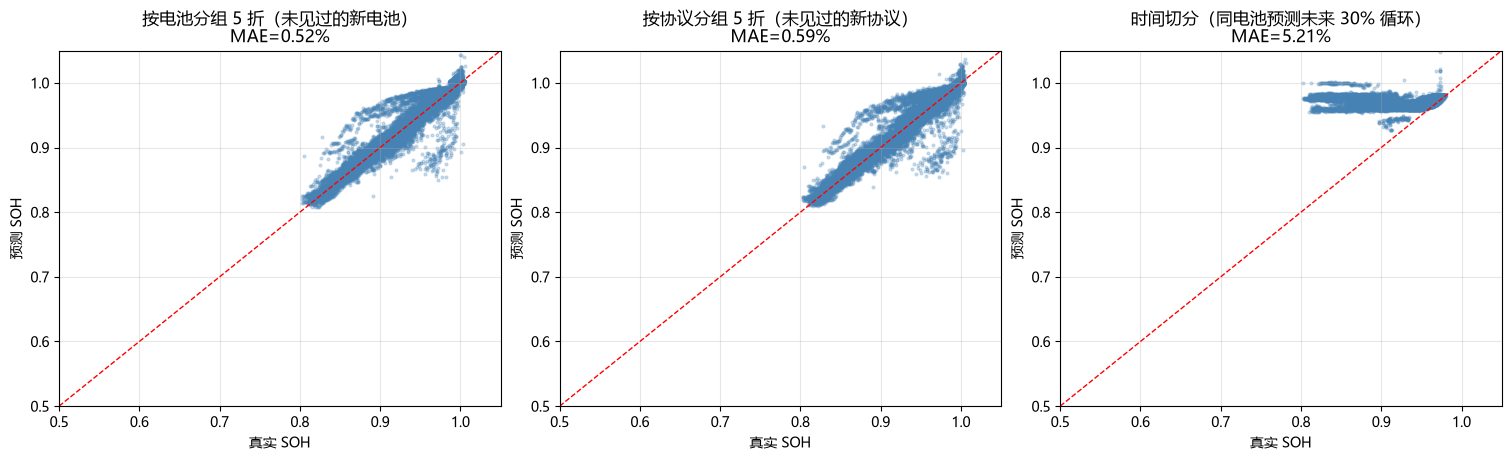

已保存： C:\Users\PLUTO\Desktop\battery-soh\results\figures\matr_baseline_pred.png


In [11]:
# ===== 预测 vs 真实（HistGradientBoosting）=====
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for ax, (scheme, label) in zip(axes, labels):
    m = results[scheme]["HistGradientBoosting"]
    ax.scatter(m["true"], m["pred"], s=4, alpha=0.25, color="steelblue")
    ax.plot([0.5, 1.05], [0.5, 1.05], "r--", lw=1)
    ax.set_title(f"{label}\nMAE={m['MAE'] * 100:.2f}%")
    ax.set_xlabel("真实 SOH")
    ax.set_ylabel("预测 SOH")
    ax.set_xlim(0.5, 1.05)
    ax.set_ylim(0.5, 1.05)
    ax.grid(alpha=0.3)

out_fig = ROOT / "results/figures/matr_baseline_pred.png"
out_fig.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_fig, dpi=200)
plt.show()
print("已保存：", out_fig)

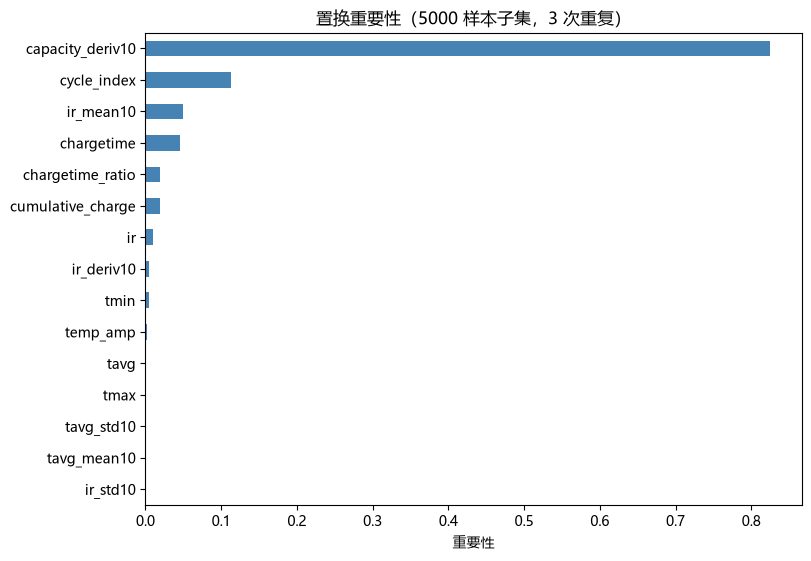

In [12]:
# ===== 特征重要性（置换重要性，可解释性）=====
from sklearn.inspection import permutation_importance

sub = features.sample(n=5000, random_state=0)
final = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=4, random_state=0)
final.fit(sub[FEATURES], sub[TARGET])
pi = permutation_importance(final, sub[FEATURES], sub[TARGET], n_repeats=3, random_state=0, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
imp.plot.barh(ax=ax, color="steelblue")
ax.set_title("置换重要性（5000 样本子集，3 次重复）")
ax.set_xlabel("重要性")
plt.show()

## 7. 结论与下一步

**A 基线已完成**：打通「数据 → 特征 → 模型 → 验证 → 指标」全链路，作为后续方案的对照基准。

**三个关键发现**：
1. 跨电池/跨协议泛化良好（MAE ≈ 0.5%），但纯逐点回归**无法时间外推**（未来 30% MAE ≈ 5%）；
2. 任务本质非线性（线性模型 R² 为负）；
3. 可解释性良好：特征重要性可支撑报告与答辩。

**下一步（B 方案）**：
1. 改为**前瞻预测**：用前 K 个循环预测第 K+Δ 个循环的 SOH，建模退化趋势；
2. 引入**原始充放电曲线片段** + 深度学习 / 物理约束模型（对标 Che et al. 2025, *Joule*：DVA 机理约束的 encoder-decoder）；
3. 加入 Stanford 动态循环数据集做动态工况交叉验证（注意其化学体系为 NCA，作为工况鲁棒性验证）。

## 参考文献

1. Severson, K.A., Attia, P.M., Jin, N. et al. Data-driven prediction of battery cycle life before capacity degradation. *Nature Energy* 4, 383–391 (2019).
2. Che, Y., Lam, V.N., Rhyu, J. et al. Diagnostic-free onboard battery health assessment. *Joule* 9, 102010 (2025).
3. 挑战杯「揭榜挂帅」赛题 CP-202612《复杂动态工况下混合动力车辆磷酸铁锂电池 SOC/SOH 高精度估计研究》比赛方案。